# Install libraries

In [1]:
!pip install pmdarima xgboost holidays openmeteo-requests requests-cache retry-requests tensorflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 777.2/777.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.0/396.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 40.3 MB/s eta 0:00:00


# Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part 1 — Load, prepare, EDA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

DATA_PATH = "/content/drive/MyDrive/time_series_60min_singleindex.csv"

df = pd.read_csv(DATA_PATH)

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

load_col = "DE_load_actual_entsoe_transparency"

de = df[[load_col]].copy()
de = de.rename(columns={load_col: "load"})

de = de.loc["2015-01-01":]
de["load"] = de["load"].interpolate()

daily = de.resample("D").mean()
weekly = de.resample("W").mean()

print(de.head())
print(daily.head())
print(weekly.head())

                              load
utc_timestamp                     
2015-01-01 00:00:00+00:00  41151.0
2015-01-01 01:00:00+00:00  40135.0
2015-01-01 02:00:00+00:00  39106.0
2015-01-01 03:00:00+00:00  38765.0
2015-01-01 04:00:00+00:00  38941.0
                                   load
utc_timestamp                          
2015-01-01 00:00:00+00:00  45346.541667
2015-01-02 00:00:00+00:00  51941.166667
2015-01-03 00:00:00+00:00  46564.750000
2015-01-04 00:00:00+00:00  45082.500000
2015-01-05 00:00:00+00:00  55246.666667
                                   load
utc_timestamp                          
2015-01-04 00:00:00+00:00  47233.739583
2015-01-11 00:00:00+00:00  56191.101190
2015-01-18 00:00:00+00:00  57672.678571
2015-01-25 00:00:00+00:00  58613.303571
2015-02-01 00:00:00+00:00  58734.029762


# Plot hourly, daily, weekly

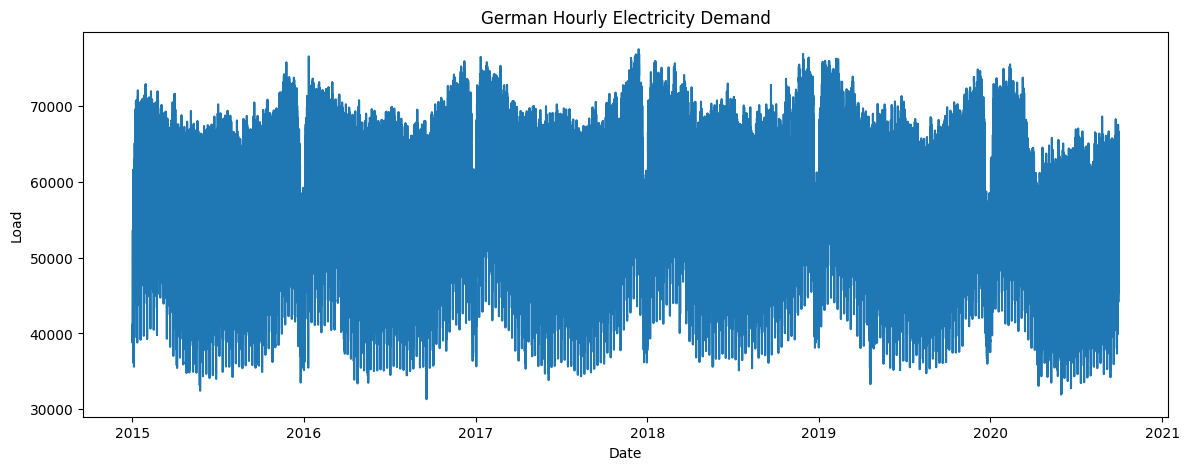

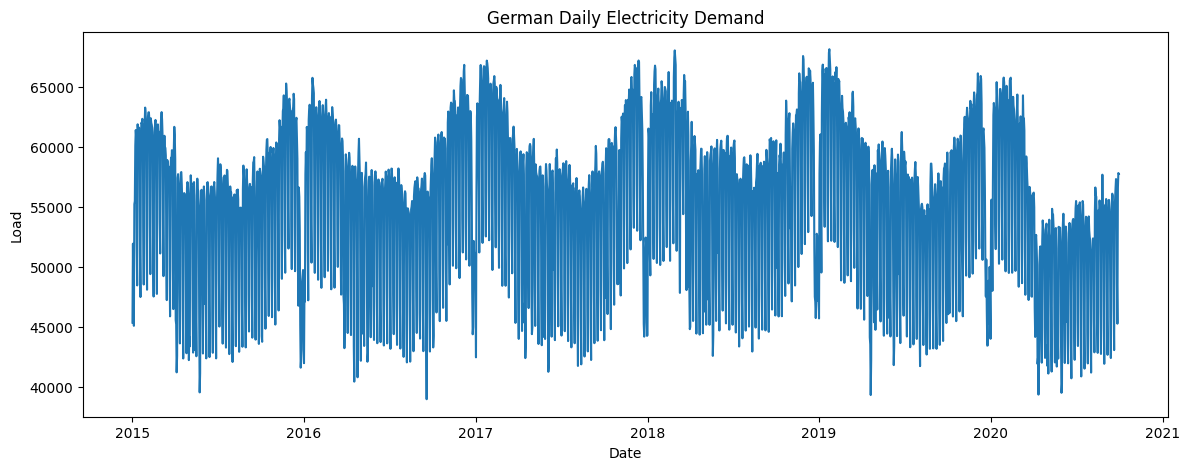

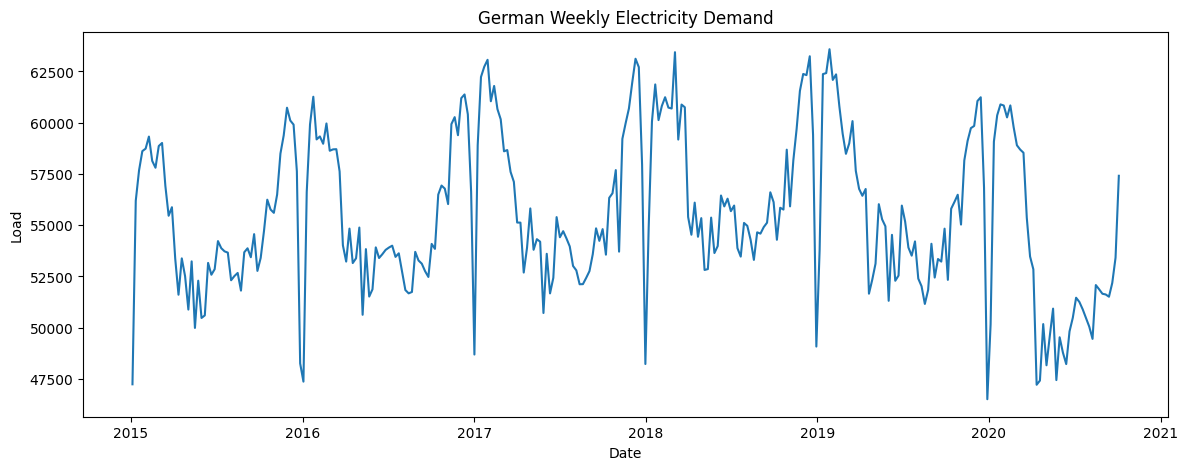

In [4]:
plt.figure(figsize=(14,5))
plt.plot(de.index, de["load"])
plt.title("German Hourly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(daily.index, daily["load"])
plt.title("German Daily Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load")
plt.show()

plt.figure(figsize=(14,5))
plt.plot(weekly.index, weekly["load"])
plt.title("German Weekly Electricity Demand")
plt.xlabel("Date")
plt.ylabel("Load")
plt.show()

# ADF and KPSS stationarity tests

In [5]:
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("ADF result: Stationary")
    else:
        print("ADF result: Non-stationary")

def kpss_test(series):
    result = kpss(series.dropna(), regression="c", nlags="auto")
    print("KPSS Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("KPSS result: Non-stationary")
    else:
        print("KPSS result: Stationary")

print("ADF Test:")
adf_test(weekly["load"])

print("\nKPSS Test:")
kpss_test(weekly["load"])

ADF Test:
ADF Statistic: -4.0474718556784826
p-value: 0.0011813497340154512
ADF result: Stationary

KPSS Test:
KPSS Statistic: 0.16037407809773105
p-value: 0.1
KPSS result: Stationary


/tmp/ipykernel_8203/545542207.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression="c", nlags="auto")


# ACF and PACF

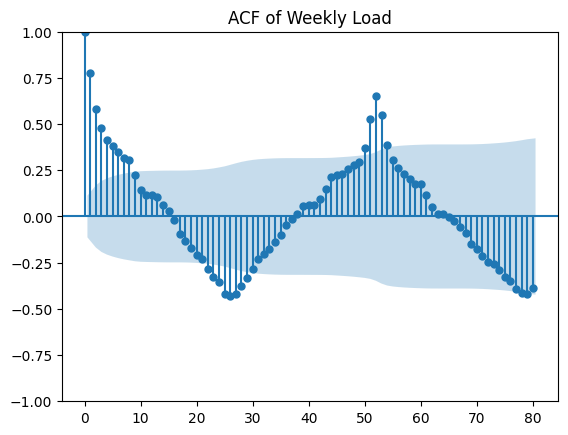

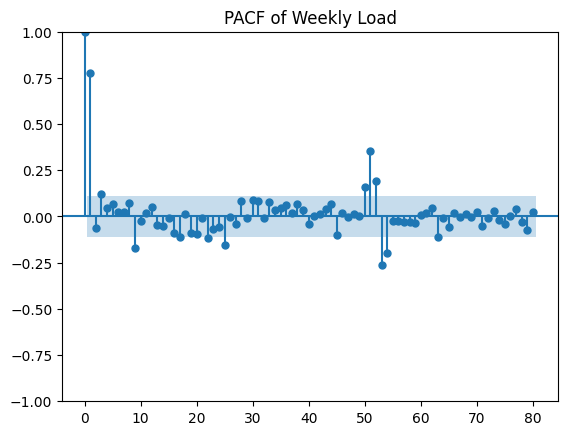

In [6]:
plot_acf(weekly["load"].dropna(), lags=80)
plt.title("ACF of Weekly Load")
plt.show()

plot_pacf(weekly["load"].dropna(), lags=80, method="ywm")
plt.title("PACF of Weekly Load")
plt.show()

# Train-test split

In [7]:
forecast_horizon = 104

train = weekly.iloc[:-forecast_horizon].copy()
test = weekly.iloc[-forecast_horizon:].copy()

print("Train:", train.index.min(), train.index.max(), train.shape)
print("Test:", test.index.min(), test.index.max(), test.shape)

Train: 2015-01-04 00:00:00+00:00 2018-10-07 00:00:00+00:00 (197, 1)
Test: 2018-10-14 00:00:00+00:00 2020-10-04 00:00:00+00:00 (104, 1)


# Metrics function

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate(actual, pred):
    actual = np.array(actual)
    pred = np.array(pred)

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100

    return rmse, mae, mape

# Benchmark models

In [9]:
benchmark_results = {}

# Mean forecast
mean_forecast = np.repeat(train["load"].mean(), len(test))

# Naive forecast
naive_forecast = np.repeat(train["load"].iloc[-1], len(test))

# Seasonal naive forecast, weekly seasonality = 52
seasonal_naive_forecast = train["load"].iloc[-52:].values
seasonal_naive_forecast = np.tile(
    seasonal_naive_forecast,
    int(np.ceil(len(test) / 52))
)[:len(test)]

# Drift forecast
y_first = train["load"].iloc[0]
y_last = train["load"].iloc[-1]
n = len(train)

drift_forecast = []
for h in range(1, len(test) + 1):
    drift_value = y_last + h * ((y_last - y_first) / (n - 1))
    drift_forecast.append(drift_value)

forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

for name, pred in forecasts.items():
    rmse, mae, mape = evaluate(test["load"], pred)
    benchmark_results[name] = [rmse, mae, mape]

benchmark_df = pd.DataFrame(
    benchmark_results,
    index=["RMSE", "MAE", "MAPE"]
).T

benchmark_df

,RMSE,MAE,MAPE
Mean,4397.299694,3788.833122,6.969238
Naive,4459.108546,3783.202934,6.790082
Seasonal Naive,3006.760812,2318.520585,4.408920
Drift,5117.957264,4339.890674,8.049685


# Plot benchmark forecasts

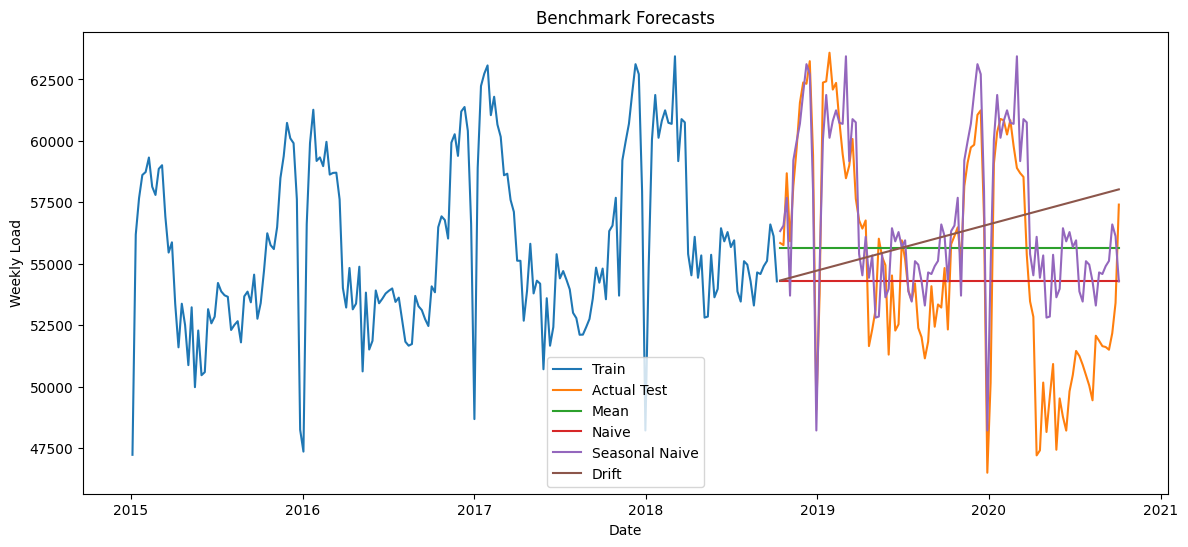

In [10]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train["load"], label="Train")
plt.plot(test.index, test["load"], label="Actual Test")

for name, pred in forecasts.items():
    plt.plot(test.index, pred, label=name)

plt.title("Benchmark Forecasts")
plt.xlabel("Date")
plt.ylabel("Weekly Load")
plt.legend()
plt.show()

# SARIMA

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3544.219, Time=15.58 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3764.053, Time=0.03 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3551.091, Time=1.18 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=inf, Time=5.97 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4866.963, Time=0.05 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3560.101, Time=4.28 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=3541.820, Time=12.38 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=3604.444, Time=0.23 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=3543.082, Time=60.44 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=inf, Time=60.77 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=3543.911, Time=5.56 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=3540.855, Time=5.01 sec
 ARIMA(2,0,1)(0,0,0)[52] intercept   : AIC=3604.756, Time=0.41 sec
 ARIMA(2,0,1)(2,0,0)[52] intercept   : AIC=3542.110, Time=51.22 sec
 ARIMA(2,0,1)(1,0,1)[52]

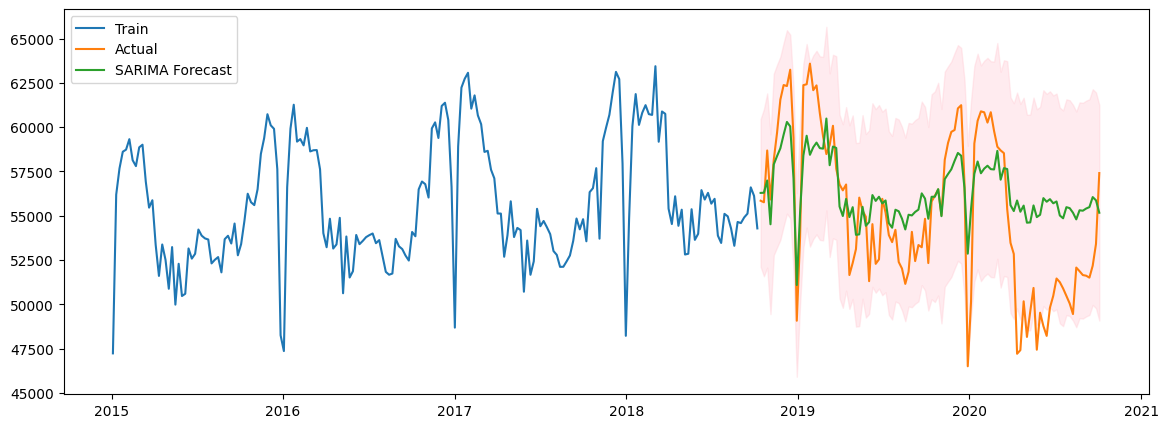

In [11]:
!pip install pmdarima -q
import pmdarima as pm
import matplotlib.pyplot as plt

sarima_model = pm.auto_arima(
    train["load"], seasonal=True, m=52, stepwise=True,
    max_p=3, max_d=1, max_q=3, max_P=2, max_D=1, max_Q=2,
    trace=True, error_action='ignore', suppress_warnings=True, n_jobs=-1
)
print("Best order:", sarima_model.order, "Seasonal order:", sarima_model.seasonal_order)

# Forecast
sarima_forecast, conf_int = sarima_model.predict(n_periods=len(test), return_conf_int=True)

# Metrics
rmse, mae, mape = evaluate(test["load"], sarima_forecast)
print(f"SARIMA -> RMSE:{rmse:.2f}, MAE:{mae:.2f}, MAPE:{mape:.2f}%")

# Plot
plt.figure(figsize=(14,5))
plt.plot(train.index, train["load"], label="Train")
plt.plot(test.index, test["load"], label="Actual")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")
plt.fill_between(test.index, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.legend()
plt.show()

# SARIMAX with Temperature

/usr/local/lib/python3.12/dist-packages/pmdarima/arima/_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=3544.219, Time=16.22 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=3764.053, Time=0.04 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=3551.091, Time=1.17 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=inf, Time=3.03 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=4866.963, Time=0.03 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=3560.101, Time=7.04 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=3541.820, Time=9.85 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=3604.444, Time=0.24 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=3543.082, Time=62.85 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=inf, Time=63.89 sec
 ARIMA(1,0,2)(1,0,0)[52] intercept   : AIC=3543.911, Time=2.55 sec
 ARIMA(2,0,1)(1,0,0)[52] intercept   : AIC=3540.855, Time=7.69 sec
 ARIMA(2,0,1)(0,0,0)[52] intercept   : AIC=3604.756, Time=0.30 sec
 ARIMA(2,0,1)(2,0,0)[52] intercept   : AIC=3542.110, Time=51.11 sec
 ARIMA(2,0,1)(1,0,1)[52] 

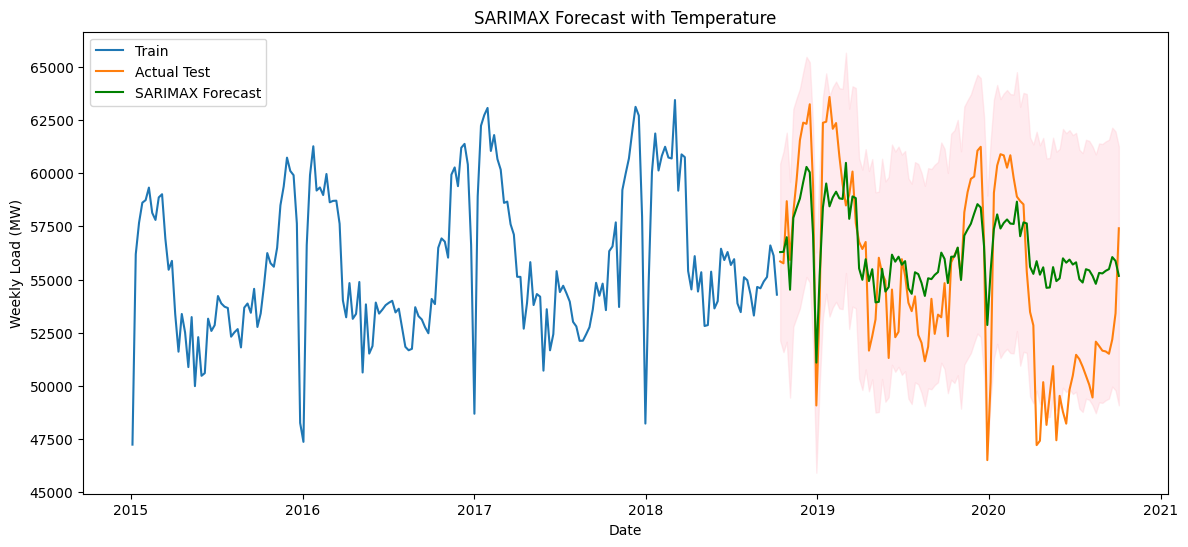

In [17]:
# Part 4: SARIMAX with Berlin Temperature (fixed tz issue)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# -----------------------------
# Evaluation function
# -----------------------------
def evaluate(actual, pred):
    actual, pred = np.array(actual), np.array(pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred)/actual))*100
    return rmse, mae, mape

# -----------------------------
# Load weekly load (from Part 1)
# -----------------------------
DATA_PATH = "/content/drive/MyDrive/time_series_60min_singleindex.csv"
df = pd.read_csv(DATA_PATH)
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

load_col = "DE_load_actual_entsoe_transparency"
de = df[[load_col]].rename(columns={load_col:"load"})
de = de.loc["2015-01-01":]
de["load"] = de["load"].interpolate()
weekly = de.resample("W").mean()

# Make weekly tz-naive explicitly
weekly.index = weekly.index.tz_localize(None)

# -----------------------------
# Fetch Berlin temperature
# -----------------------------
latitude, longitude = 52.52, 13.41
start_date, end_date = "2015-01-01", "2020-10-06"

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}&longitude={longitude}"
    f"&start_date={start_date}&end_date={end_date}"
    "&hourly=temperature_2m&timezone=UTC"
)
weather = requests.get(url).json()

temp = pd.DataFrame({
    "time": weather["hourly"]["time"],
    "temperature": weather["hourly"]["temperature_2m"]
})
temp["time"] = pd.to_datetime(temp["time"])
temp = temp.set_index("time")

# Resample to weekly
weekly_temp = temp.resample("W").mean()

# Make temperature tz-naive as well
weekly_temp.index = weekly_temp.index.tz_localize(None)

# -----------------------------
# Join load with temperature
# -----------------------------
weekly_exog = weekly.join(weekly_temp, how="left")
weekly_exog["temperature"] = weekly_exog["temperature"].interpolate()

# -----------------------------
# Train-test split
# -----------------------------
forecast_horizon = 104  # last 2 years
train_exog = weekly_exog.iloc[:-forecast_horizon]
test_exog = weekly_exog.iloc[-forecast_horizon:]

X_train = train_exog[["temperature"]]
X_test = test_exog[["temperature"]]

# -----------------------------
# Fit SARIMAX using auto_arima
# -----------------------------
sarimax_model = pm.auto_arima(
    train_exog["load"],
    exogenous=X_train,
    seasonal=True,
    m=52,
    stepwise=True,
    max_p=3, max_d=1, max_q=3,
    max_P=2, max_D=1, max_Q=2,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    n_jobs=-1
)

# -----------------------------
# Forecast
# -----------------------------
sarimax_forecast, conf_int = sarimax_model.predict(
    n_periods=len(X_test),
    exogenous=X_test,
    return_conf_int=True
)

# -----------------------------
# Evaluate
# -----------------------------
rmse, mae, mape = evaluate(test_exog["load"], sarimax_forecast)
print(f"SARIMAX -> RMSE: {rmse:.2f}, MAE: {mae:.2f}, MAPE: {mape:.2f}%")

# -----------------------------
# Plot forecast
# -----------------------------
plt.figure(figsize=(14,6))
plt.plot(train_exog.index, train_exog["load"], label="Train")
plt.plot(test_exog.index, test_exog["load"], label="Actual Test")
plt.plot(test_exog.index, sarimax_forecast, label="SARIMAX Forecast", color='green')
plt.fill_between(test_exog.index, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.title("SARIMAX Forecast with Temperature")
plt.xlabel("Date")
plt.ylabel("Weekly Load (MW)")
plt.legend()
plt.show()

# Feature-based ML model

In [22]:
# Part 5: Random Forest / Gradient Boosting
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
ml_data = weekly_exog.copy()  # weekly data
ml_data["lag_1"] = ml_data["load"].shift(1)
ml_data["lag_2"] = ml_data["load"].shift(2)
ml_data["lag_52"] = ml_data["load"].shift(52)
ml_data["rolling_4"] = ml_data["load"].shift(1).rolling(4).mean()
ml_data = ml_data.dropna()

ml_train = ml_data.iloc[:-forecast_horizon]
ml_test = ml_data.iloc[-forecast_horizon:]

features = ["temperature","lag_1","lag_2","lag_52","rolling_4"]
X_train, y_train = ml_train[features], ml_train["load"]
X_test, y_test = ml_test[features], ml_test["load"]

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rmse, mae, mape = evaluate(y_test, rf_pred)
print(f"Random Forest -> RMSE:{rmse:.2f}, MAE:{mae:.2f}, MAPE:{mape:.2f}%")

Random Forest -> RMSE:2544.28, MAE:1837.02, MAPE:3.54%


# Random forest

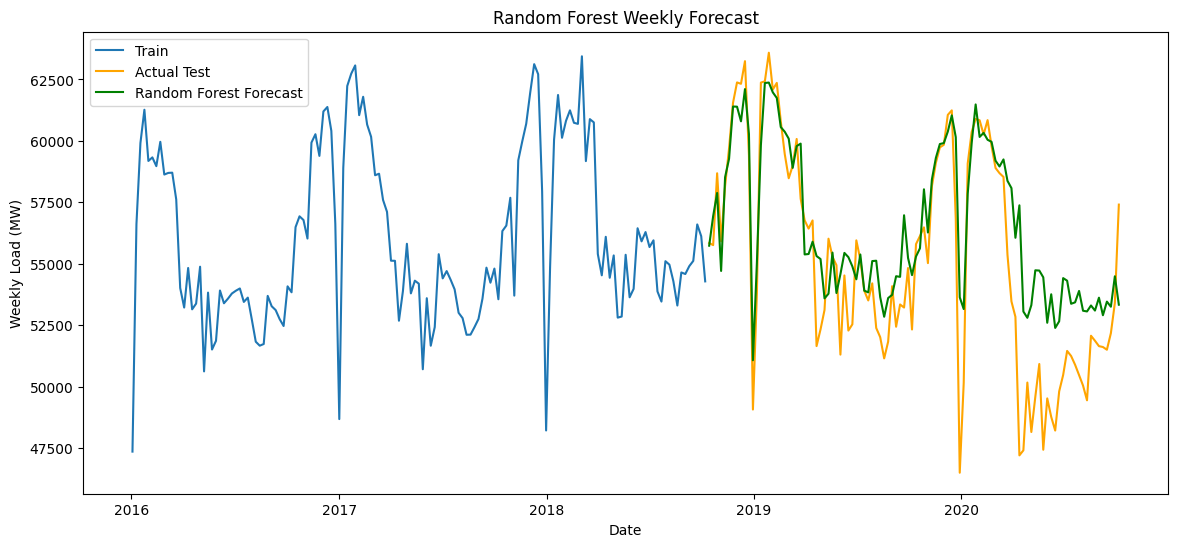

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(ml_train.index, ml_train["load"], label="Train")
plt.plot(ml_test.index, y_test, label="Actual Test", color="orange")
plt.plot(ml_test.index, rf_pred, label="Random Forest Forecast", color="green")
plt.title("Random Forest Weekly Forecast")
plt.xlabel("Date")
plt.ylabel("Weekly Load (MW)")
plt.legend()
plt.show()

# LSTM for hourly data

In [19]:
# Part 6: LSTM
!pip install tensorflow -q
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

hourly = de.copy().dropna()
train_hourly = hourly.iloc[:-24*365*2]
test_hourly = hourly.iloc[-24*365*2:]

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_hourly)
test_scaled = scaler.transform(test_hourly)

# Create sequences
def create_seq(data, window=168):
    X, y = [], []
    for i in range(window,len(data)):
        X.append(data[i-window:i,0])
        y.append(data[i,0])
    return np.array(X).reshape(-1,window,1), np.array(y)

window=168
X_train, y_train = create_seq(train_scaled, window)
combined_scaled = np.concatenate([train_scaled[-window:], test_scaled])
X_test, y_test = create_seq(combined_scaled, window)

# Build LSTM
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(window,1)))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer="adam", loss="mse")

model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, shuffle=False)

# Forecast
lstm_pred_scaled = model.predict(X_test)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))
rmse, mae, mape = evaluate(y_test_actual.flatten(), lstm_pred.flatten())
print(f"LSTM -> RMSE:{rmse:.2f}, MAE:{mae:.2f}, MAPE:{mape:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 126s 150ms/step - loss: 0.0170 - val_loss: 0.0077
Epoch 2/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 134s 140ms/step - loss: 0.0059 - val_loss: 0.0045
Epoch 3/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 121s 148ms/step - loss: 0.0043 - val_loss: 0.0040
Epoch 4/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 117s 143ms/step - loss: 0.0032 - val_loss: 0.0019
Epoch 5/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 117s 143ms/step - loss: 0.0025 - val_loss: 0.0021
Epoch 6/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 116s 142ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 7/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 115s 141ms/step - loss: 0.0017 - val_loss: 0.0012
Epoch 8/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 146s 145ms/step - loss: 0.0015 - val_loss: 0.0013
Epoch 9/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 115s 141ms/step - loss: 0.0013 - val_loss: 7.4270e-04
Epoch 10/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 144s 143ms/step - loss: 0.0012 - val_loss: 7.2929e-04
Epoch 11/20
818/818 ━━━━━━━━━━━━━━━━━━━━ 117s 143ms/step - loss: 0.0012 - val_loss: 7.4578e

#  Plot LSTM forecast vs actual

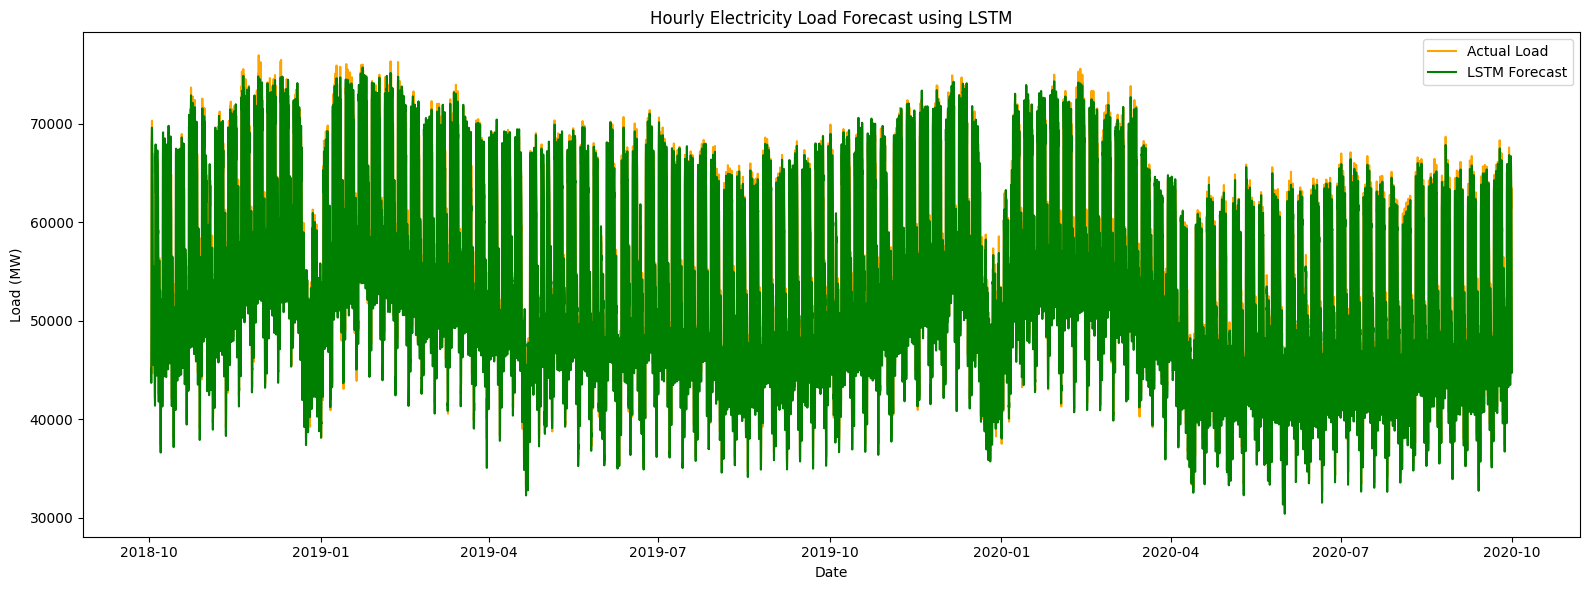

In [20]:
import matplotlib.pyplot as plt

# Create a time index for the test period
lstm_test_index = test_hourly.index[:len(lstm_pred)]

plt.figure(figsize=(16,6))
plt.plot(lstm_test_index, y_test_actual.flatten(), label="Actual Load", color="orange")
plt.plot(lstm_test_index, lstm_pred.flatten(), label="LSTM Forecast", color="green")
plt.title("Hourly Electricity Load Forecast using LSTM")
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.legend()
plt.tight_layout()
plt.show()